# 01 - Primary Analysis: PaySim Financial Transaction Dataset

**Project:** Anomaly Watchers - Fraud Detection Pipeline  
**Dataset:** Kaggle PaySim Synthetic Mobile-Money Transactions  
**Objective:** Transform raw transaction data into a clean Feature Matrix suitable for incremental online-learning classifiers.

---

## Notebook Roadmap

| Phase | Section                                | Purpose                                                                                     |
| ----- | -------------------------------------- | ------------------------------------------------------------------------------------------- |
| 1     | Import Libraries and Data Ingestion    | Load dependencies, configure logger, and establish memory-efficient streaming.              |
| 2     | Exploratory Data Analysis (EDA)        | Measure class skew and analyze fraud distribution across transaction types.                 |
| 3     | Data Leakage Prevention                | Remove post-transaction features to ensure rigorous pre-transaction classification.         |
| 4     | Feature Engineering                    | Construct financial ratios, logarithmic transforms, and cyclical temporal features.         |
| 5     | One-Hot Encoding & Dummy Variable Trap | Encode categorical variables while preserving matrix rank and resolving multicollinearity.  |
| 6     | Modular Pipeline Encapsulation         | Assemble the ETL pipeline using Pandas `.pipe()` and validate the schema.                   |
| 7     | Train/Test Splitting & Leakage Defense | Isolate a clean test set prior to synthetic minority oversampling (SMOTE).                  |
| 8     | Three-Model Pipeline Execution         | Train Baseline (LR), Primary (XGBoost + SMOTE), and Unsupervised (Isolation Forest) models. |
| 9     | Business-Centric Evaluation & XAI      | Evaluate via AUPRC/F1-Score, analyze Confusion Matrices, and extract Feature Importances.   |
| 10    | Artifact Serialization                 | Export pipeline and trained models strictly to the backend directory for API integration.   |

## 1. Import Libraries and Data Ingestion

We begin by preparing our Python environment and importing the core libraries required for this analysis.  
The column names from the raw Kaggle export use inconsistent formatting (`nameOrig`, `oldbalanceOrg`, etc.).  
We will immediately rename them to clean, standard `snake_case` format so that every following step refers to a clear and unified structure.


### 1.1 Import Libraries, Environment Setup & Version Report

We skip installing over the existing Jupyter kernel and directly import the necessary libraries, relying on the OS-optimised versions installed in the environment.


In [1]:
# =====================================================================
# 1.1.1 Define SimpleLogger (to print color-coded log messages)
# =====================================================================

class SimpleLogger:
    def __init__(self):
        self.CYAN = '\033[96m'
        self.GREEN = '\033[92m'
        self.YELLOW = '\033[93m'
        self.RED = '\033[91m'
        self.RESET = '\033[0m'
    def info(self, msg): print(f"{self.CYAN}[INFO] {msg}{self.RESET}")
    def success(self, msg): print(f"{self.GREEN}[SUCCESS] {msg}{self.RESET}")
    def warning(self, msg): print(f"{self.YELLOW}[WARNING] {msg}{self.RESET}")
    def error(self, msg): print(f"{self.RED}[ERROR] {msg}{self.RESET}")

logger = SimpleLogger()

In [2]:
# =====================================================================
# 1.1.2 Dependency Manager
# =====================================================================

import sys
import subprocess
import importlib.metadata
import os
import io

# Define required packages (Import Name : Install Name)
REQUIRED_PACKAGES = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'kagglehub': 'kagglehub',
    'dotenv': 'python-dotenv',
    'xgboost': 'xgboost',
    'imblearn': 'imbalanced-learn',
    'sklearn': 'scikit-learn'
}

In [3]:
# =====================================================================
# 1.1.3 Setup Environment & Install Missing Libraries
# =====================================================================

def setup_environment():
    """Checks for required packages and securely installs only those missing."""
    logger.info("Initiating Dependency Manager...")
    installed_packages = {pkg.metadata['Name'].lower() for pkg in importlib.metadata.distributions()}
    
    for import_name, install_name in REQUIRED_PACKAGES.items():
        if install_name.lower() not in installed_packages:
            logger.warning(f"{install_name} missing. Installing into active kernel...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', install_name])
            logger.success(f"{install_name} installed.")
        else:
            pass # Package exists, skip to comply with strict environment rules
            
# Execute Environment Setup
setup_environment()

[INFO] Initiating Dependency Manager...


In [4]:
# Environment Sanitization
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", module="tqdm.*")

In [5]:
# =====================================================================
# 1.1.4 Imports Libraries Safely
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

logger.success("Libraries imported safely and environment warnings suppressed.")

[SUCCESS] Libraries imported safely and environment warnings suppressed.


In [6]:
# =====================================================================
# 1.1.5 Dynamically Report Environment Versions for Reproducibility
# =====================================================================

logger.info("Environment Versions:")
logger.info(f"Python     : {sys.version.split()[0]}")
for import_name, install_name in REQUIRED_PACKAGES.items():
    try:
        version = importlib.metadata.version(install_name)
        logger.info(f"{install_name.ljust(10)} : {version}")
    except importlib.metadata.PackageNotFoundError:
        logger.error(f"Failed to resolve version for {install_name}")

logger.success("All libraries imported and validated successfully.")

[INFO] Environment Versions:
[INFO] Python     : 3.13.5
[INFO] pandas     : 3.0.1
[INFO] numpy      : 2.4.3
[INFO] matplotlib : 3.10.8
[INFO] seaborn    : 0.13.2
[INFO] kagglehub  : 1.0.0
[INFO] python-dotenv : 1.2.2
[INFO] xgboost    : 3.2.0
[INFO] imbalanced-learn : 0.14.1
[INFO] scikit-learn : 1.8.0
[SUCCESS] All libraries imported and validated successfully.


### 1.2 Secure Data Ingestion (KaggleHub)

Load full ~6 million transaction dataset from KaggleHub.


In [7]:
import kagglehub
from dotenv import load_dotenv
from pathlib import Path

# 1. Initialize Environment & Memory Mapping
load_dotenv()
logger.info("Initializing Secure Data Ingestion...")

# Strict memory typing to compress the 6.3M rows and prevent system RAM OOM crashes
dtype_map = {
    'step': 'int16',
    'type': 'category',
    'amount': 'float32',
    'nameOrig': 'object',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'object',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8'
}

# 2. Verify Authentication Context
if os.environ.get('KAGGLE_USERNAME'):
    logger.info("Kaggle credentials verified in environment.")
else:
    logger.warning("Kaggle credentials not found. Public datasets may still download anonymously.")

try:
    # 3. Securely fetch the target dataset payload via Kaggle API
    logger.info("Requesting 'ealaxi/paysim1' dataset from Kaggle...")
    dataset_path = kagglehub.dataset_download("ealaxi/paysim1")

    # Dynamically fetch the current user's home directory (Works on Windows/Mac/Linux)
    user_home = str(Path.home())

    # Sanitize the local system path for professional logging
    sanitized_path = dataset_path.replace(user_home, '<USER_HOME>')

    logger.success(f"Dataset securely downloaded and located at: {sanitized_path}")

    # 4. Locate the specific CSV file within the payload directory
    csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
    
    if not csv_files:
        logger.error(f"No CSV files found in the target directory: {dataset_path}")
    else:
        csv_file_path = os.path.join(dataset_path, csv_files[0])
        logger.info(f"Target CSV located: '{csv_files[0]}'. Loading entirely into memory...")

        # 5. Direct Memory Load
        # Relies entirely on dtype_map to survive the ~6.3 million row memory allocation
        raw_df = pd.read_csv(csv_file_path, dtype=dtype_map)
        
        logger.success("Full dataset successfully loaded into memory.")
        
        # 6. Initialize working DataFrame
        df = raw_df.copy()
        logger.success(f"Working DataFrame initialised. Shape: {df.shape}")
        display(df.head())

except Exception as e:
    logger.error(f"Data ingestion pipeline failed. Error: {str(e)}")

[INFO] Initializing Secure Data Ingestion...
[INFO] Kaggle credentials verified in environment.
[INFO] Requesting 'ealaxi/paysim1' dataset from Kaggle...
[SUCCESS] Dataset securely downloaded and located at: <USER_HOME>\.cache\kagglehub\datasets\ealaxi\paysim1\versions\2
[INFO] Target CSV located: 'PS_20174392719_1491204439457_log.csv'. Loading entirely into memory...
[SUCCESS] Full dataset successfully loaded into memory.
[SUCCESS] Working DataFrame initialised. Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0


### 1.3 Rename Columns to Snake Case

The raw Kaggle columns use inconsistent camelCase (e.g., `nameOrig`, `oldbalanceOrg`).  
We define the pure function `rename_to_snake_case()` and immediately execute it on `df`, establishing a consistent `snake_case` schema for the entire pipeline.


In [8]:
def rename_to_snake_case(df):
    """Rename raw Kaggle camelCase columns to a unified snake_case schema."""
    COLUMN_MAP = {
        "step":            "step",
        "type":            "transaction_type",
        "amount":          "transaction_amount",
        "nameOrig":        "originator_id",
        "oldbalanceOrg":   "originator_old_balance",
        "newbalanceOrig":  "originator_new_balance",
        "nameDest":        "destination_id",
        "oldbalanceDest":  "destination_old_balance",
        "newbalanceDest":  "destination_new_balance",
        "isFraud":         "is_fraud",
        "isFlaggedFraud":  "is_flagged_fraud",
    }
    return df.rename(columns=COLUMN_MAP)

df = rename_to_snake_case(df)

logger.success("Columns renamed to snake_case schema:")
logger.info(str(df.columns.tolist()))

[SUCCESS] Columns renamed to snake_case schema:
[INFO] ['step', 'transaction_type', 'transaction_amount', 'originator_id', 'originator_old_balance', 'originator_new_balance', 'destination_id', 'destination_old_balance', 'destination_new_balance', 'is_fraud', 'is_flagged_fraud']


## 2. EDA (Exploratory Data Analysis): Defining the Evaluation Framework and Class Distribution

### The Flaw in Accuracy Metric
Financial transaction datasets contain severe class imbalances, where legitimate activities outnumber fraudulent events by orders of magnitude. Because of this, standard Accuracy is mathematically deceptive when evaluating model performance.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

In an enterprise fraud dataset, True Negatives ($TN$, legitimate transactions correctly identified) number in the millions, while True Positives ($TP$, actual fraud caught) and False Negatives ($FN$, missed fraud) number only in the low thousands.

Looking at the formula, the massive $TN$ value completely dominates both the top and the bottom of the fraction. For example, if a dataset has 1,000,000 legitimate transactions and 1,000 fraudulent ones, a baseline model that blindly guesses "legitimate" for every single transaction will yield:

* $TP = 0$
* $TN = 1,000,000$
* $FP = 0$
* $FN = 1,000$

$$\text{Accuracy} = \frac{0 + 1,000,000}{0 + 1,000,000 + 0 + 1,000} = 99.9\%$$

This model achieves 99.9% accuracy but catches exactly zero actual fraud, resulting in unmitigated financial loss for the institution. We strictly reject Accuracy as an evaluation metric for this architecture.

### Reliable Metrics in this Context

* **AUPRC (Area Under the Precision-Recall Curve)**: Evaluates the precision-recall trade-off exclusively on the minority class. Because the $TN$ variable is completely removed from Precision and Recall calculations, this metric is unaffected by the massive volume of legitimate transactions.
* **F1-Score**: Establishes a harmonic mean between Precision and Recall. Maximizing this metric ensures the architecture mathematically balances false negatives (direct financial loss) against false positives (severe customer friction).


### 2.1 Class Skew Quantification

We map the dataset classes on a log-scaled axis to expose the absolute volume of the imbalance.

[INFO] Class Distribution:
is_fraud
0    6354407
1       8213
[INFO] Fraud prevalence: 0.1291 %


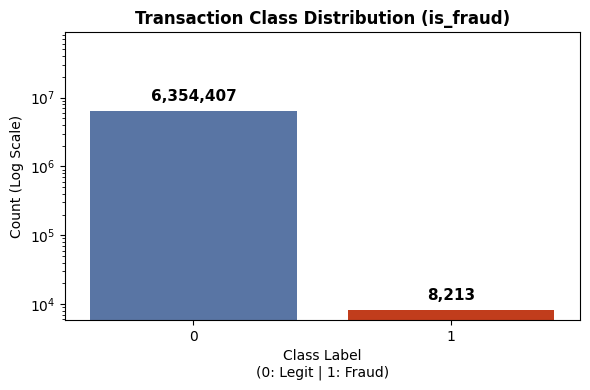

In [9]:
# Generate categorical plot to determine exact imbalance ratio

fraud_counts = df["is_fraud"].value_counts()
fraud_pct    = df["is_fraud"].value_counts(normalize=True) * 100

logger.info(f"Class Distribution:\n{fraud_counts.to_string()}")
logger.info(f"Fraud prevalence: {fraud_pct[1]:.4f} %")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(
    x="is_fraud", 
    data=df, 
    ax=ax,
    hue="is_fraud", 
    palette={0: "#4C72B0", 1: "#DD2C00", "0": "#4C72B0", "1": "#DD2C00"}, 
    legend=False
)

ax.set_title("Transaction Class Distribution (is_fraud)", fontweight="bold")
ax.set_xlabel("Class Label\n(0: Legit | 1: Fraud)")
ax.set_ylabel("Count (Log Scale)")
ax.set_yscale("log")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 10) # Multiply by 10 to add a full "log order" of space above the bar

for p in ax.patches:
    # Adding a small pixel offset to the Y position for cleaner spacing
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold",
                xytext=(0, 5), textcoords='offset points') # Pushes text 5 pixels up

plt.tight_layout()
plt.show()

#### Interpretation: Transaction Class Imbalance

- **Observation**: The matrix contains 6,354,407 legitimate transactions against exactly 8,213 fraudulent transactions, establishing a 774:1 legitimate-to-fraud imbalance ratio.

- **Implication**: Without structural intervention, gradient boosting algorithms will minimize global error by predicting the majority class exclusively, rendering the model useless for anomaly detection.

- **Decision**: We must enforce class parity during the training phase using SMOTE. This will be encapsulated within a cross-validation pipeline to guarantee the algorithm learns the minority class boundaries without triggering data leakage into the validation folds.


### 2.2 Analyse Fraud Distribution Across Transaction Types

Not all transaction types carry the same fraud risk. We compute the absolute fraud count and the fraud rate (%) for each `transaction_type` to understand where fraud is happening.

[INFO] Fraud breakdown by transaction type:


,fraud_count,total_count,fraud_rate_%
transaction_type,,,
TRANSFER,4097,532909,0.7688
CASH_OUT,4116,2237500,0.1840
CASH_IN,0,1399284,0.0000
DEBIT,0,41432,0.0000
PAYMENT,0,2151495,0.0000


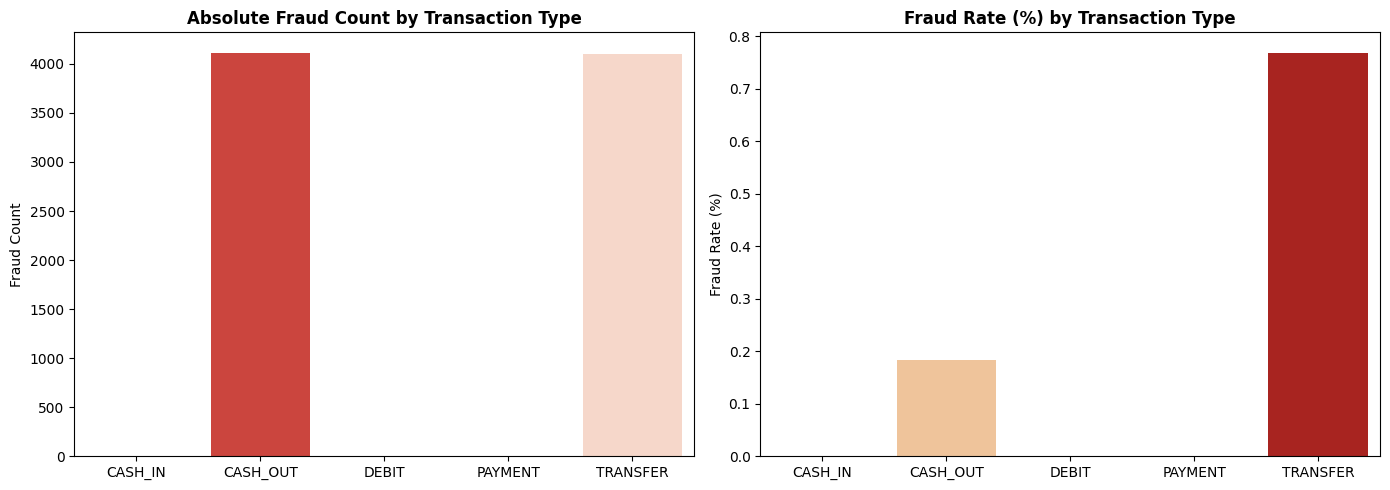

In [10]:
# Group target label by transaction type to isolate vulnerability vectors

type_fraud = df.groupby("transaction_type")["is_fraud"].agg(["sum", "count"])
type_fraud.columns = ["fraud_count", "total_count"]
type_fraud["fraud_rate_%"] = (type_fraud["fraud_count"] / type_fraud["total_count"] * 100).round(4)
type_fraud = type_fraud.sort_values("fraud_rate_%", ascending=False)

logger.info("Fraud breakdown by transaction type:")
display(type_fraud)

# Reset the index so 'transaction_type' becomes a standard column for Seaborn
type_fraud_plot = type_fraud.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute fraud count per type
sns.barplot(
    x="transaction_type", 
    y="fraud_count", 
    data=type_fraud_plot,
    ax=axes[0], 
    palette="Reds_r", 
    hue="transaction_type", 
    dodge=False,
    legend=False
)
axes[0].set_title("Absolute Fraud Count by Transaction Type", fontweight="bold")
axes[0].set_ylabel("Fraud Count")
axes[0].set_xlabel("")

# Right: fraud rate (%) per type
sns.barplot(
    x="transaction_type", 
    y="fraud_rate_%", 
    data=type_fraud_plot,
    ax=axes[1], 
    palette="OrRd", 
    hue="transaction_type", 
    dodge=False,
    legend=False
)
axes[1].set_title("Fraud Rate (%) by Transaction Type", fontweight="bold")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

#### Interpretation: Distribution of Fraudulent Transactions by Transaction Type

- **Observation:** Fraud is found exclusively in TRANSFER (4,097 cases) and CASH_OUT (4,116 cases) transactions. There are zero recorded instances of fraud in the CASH_IN, DEBIT, and PAYMENT categories.

- **Implication**: Criminals specifically exploit transfers to move stolen capital rapidly across mule accounts, followed by cash withdrawals to extract the funds. Conversely, the `CASH_IN` transaction type represents a 100% safe operational baseline.

- **Decision**: We one-hot encode the transaction types to preserve these high-risk feature signals. To mathematically resolve the Dummy Variable Trap (perfect multicollinearity), we deliberately delete the `CASH_IN` dummy, since it is a 100% safe operational baseline. This establishes a mathematically stable, zero-risk baseline for the linear algorithms to reference.

### 2.3 Financial Scale Normalization

We assess the distribution of capital movement to determine numerical stability.

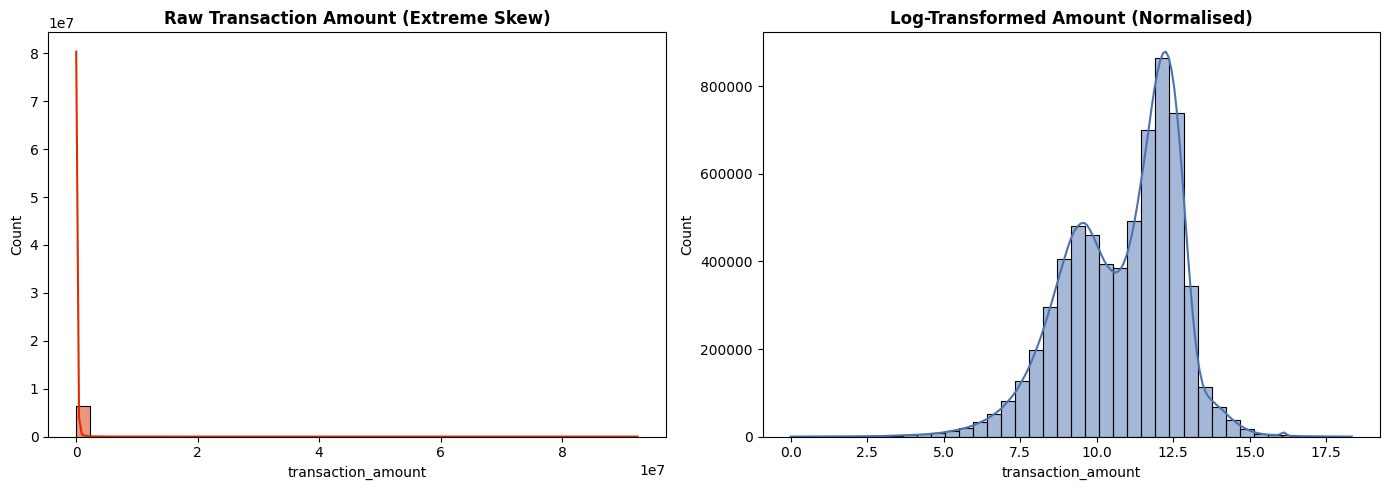

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw distribution (heavily skewed)
sns.histplot(df['transaction_amount'], bins=40, ax=axes[0], color='#DD2C00', kde=True)
axes[0].set_title('Raw Transaction Amount (Extreme Skew)', fontweight='bold')
axes[0].set_ylabel('Count')

# Plot 2: Log-transformed distribution (normalized)
sns.histplot(np.log1p(df['transaction_amount']), bins=40, ax=axes[1], color='#4C72B0', kde=True)
axes[1].set_title('Log-Transformed Amount (Normalised)', fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Interpretation: Transaction Amount Skewness

- **Observation**: Raw `transaction_amount` exhibits massive right-tail skewness. The vast majority of transfers are small, while extreme outliers extend into the tens of millions.

- **Implication**: Feeding unbounded monetary outliers into machine learning algorithms distorts gradient updates. It forces tree architectures to build deep, overfitted branches to accommodate scale variance, and destroys linear separation boundaries.

- **Decision**: We apply a strict logarithmic transformation ($\ln(1+x)$) to compress the financial scale into a stable, compact distribution. This ensures the models evaluate transaction behavior symmetrically without being skewed by multi-million dollar anomalies.


### 2.4 Visualise the Transaction Volume by Step of Hours

We isolate the timestamp data to determine if malicious actors operate on different chronological cycles than legitimate customers, and to identify structural flaws in how linear time is recorded.

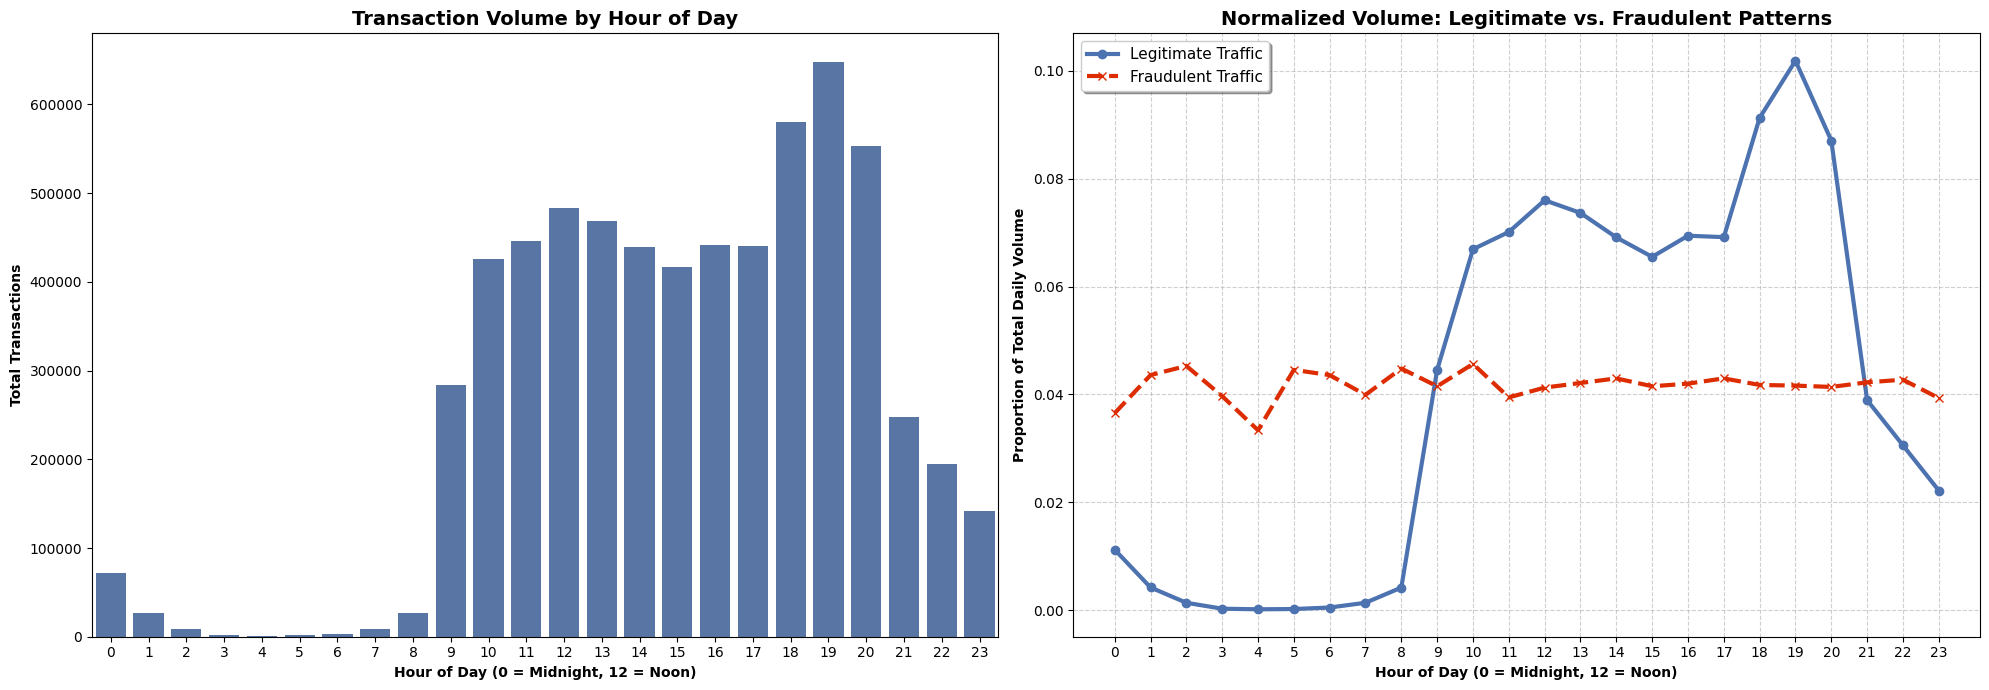

In [12]:
# Prepare data
df["hour_of_day"] = df["step"] % 24
legit_hourly = (
    df[df["is_fraud"] == 0]["hour_of_day"].value_counts(normalize=True).sort_index()
)
fraud_hourly = (
    df[df["is_fraud"] == 1]["hour_of_day"].value_counts(normalize=True).sort_index()
)

# Initialize side-by-side subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# --- LEFT PLOT: Raw Transaction Volume ---
sns.countplot(x=df["hour_of_day"], color="#4C72B0", ax=ax[0])
ax[0].set_title("Transaction Volume by Hour of Day", fontweight="bold", fontsize=14)
ax[0].set_xlabel("Hour of Day (0 = Midnight, 12 = Noon)", fontweight="bold")
ax[0].set_ylabel("Total Transactions", fontweight="bold")

# --- RIGHT PLOT: Normalized Patterns (Legit vs Fraud) ---
ax[1].plot(
    legit_hourly.index,
    legit_hourly.values,
    color="#4C72B0",
    label="Legitimate Traffic",
    linewidth=3,
    marker="o",
)
ax[1].plot(
    fraud_hourly.index,
    fraud_hourly.values,
    color="#DD2C00",
    label="Fraudulent Traffic",
    linewidth=3,
    marker="x",
    linestyle="--",
)

ax[1].set_title(
    "Normalized Volume: Legitimate vs. Fraudulent Patterns", fontweight="bold", fontsize=14
)
ax[1].set_xlabel("Hour of Day (0 = Midnight, 12 = Noon)", fontweight="bold")
ax[1].set_ylabel("Proportion of Total Daily Volume", fontweight="bold")
ax[1].set_xticks(range(0, 24))
ax[1].legend(fontsize=11, shadow=True)
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Clean up and Log
df.drop(columns=["hour_of_day"], inplace=True)

#### Interpretation: Transaction Patterns by Step of Hours Analysis

- **Observation**: The data presents two distinct structural patterns. First, legitimate transaction volume strictly mirrors a diurnal human sleep cycle, dropping to near zero between hours 0 and 6, while fraudulent transaction volume remains completely flat across the entire 24-hour cycle. Second, the raw `step` feature records time as a linear integer, placing midnight (Hour 0) and 11 PM (Hour 23) at opposite ends of the numerical scale.

- **Implication**: The flat fraud distribution indicates that fraudsters do not manually execute transfers; they deploy automated botnets. Because legitimate traffic drops at night while bot traffic remains constant, the *relative probability* of a transaction being fraudulent is highest during off-peak hours. However, if the pipeline relies on linear timestamps, the algorithm mathematically fails to recognize that Hour 23 and Hour 0 form a continuous high-risk nocturnal window.

- **Decision**: We extract the hour and project it onto a continuous 24-hour circle using trigonometric sine and cosine functions. This dual-feature engineering eliminates linear time distortion (mathematically linking 11 PM to midnight) and enables the architecture to accurately detect automated, off-peak botnet threats.

---

## 3. Data Leakage Prevention


### What Is Data Leakage?

**Data leakage** occurs when the training data contains information that would **not be available at prediction time** in a real-world system.  
A model trained on leaked features will appear to perform well during offline evaluation but will fail in real usage.

In a live banking API, the fraud-detection model is called **before** the transaction is accepted and processed.  
At prediction time, we know:

- The requested `transaction_amount`
- The current (`old`) balances of both accounts

We do **not** know:

- The **post-transaction** (`new`) balances, because the bank has not yet processed the transaction.

If we include `originator_new_balance` or `destination_new_balance` as features, we give the model information from the "future".  
The model will easily learn that `new_balance = old_balance - amount` for legitimate transactions and flag any differences.  
This is **not a true pattern of fraud**; it is just a mathematical side-effect that will not exist when we try to detect fraud in real-time.

> **Strategy:** We always drop these columns before doing any feature engineering to make sure our algorithm only sees information that would truly be available.


### 3.1 Drop Leaked Post-Transaction Balance Columns

We remove the `originator_new_balance` and `destination_new_balance` columns from the DataFrame.


In [13]:
LEAKED_COLUMNS = [
    "originator_new_balance", 
    "destination_new_balance", 
    "is_flagged_fraud"
    ]

def drop_post_transaction_leaks(df):
    """Remove columns that represent post-transaction state — unavailable at real-time prediction."""
    return df.drop(columns=LEAKED_COLUMNS)

df = drop_post_transaction_leaks(df)

logger.success(f"Dropped post-transaction leaked columns: {LEAKED_COLUMNS}")
logger.info(f"Remaining DataFrame shape: {df.shape}")

[SUCCESS] Dropped post-transaction leaked columns: ['originator_new_balance', 'destination_new_balance', 'is_flagged_fraud']
[INFO] Remaining DataFrame shape: (6362620, 8)


## 4. Feature Engineering: Mathematical Extraction of Behavioral Signatures

**Strategic Feature Construction**

Raw financial data merely records state changes. To satisfy the project objective of detecting complex anomalies, we must mathematically engineer new features that explicitly translate criminal intent and behavior into numerical boundaries.

### Summary of Engineered Features


| Feature | Formula | Business Logic & Justification |
| --- | --- | --- |
| `amount_to_destination_ratio` | $\frac{amount}{dest\_old\_bal + 1.0}$ | Detects anomalous inflows. Measures the incoming capital relative to the destination's existing wealth. |
| `account_drain_ratio` | $\frac{amount}{orig\_old\_bal + 1.0}$ | Detects account compromises. Fraudsters attempt to extract 100% of an account's available funds in a single event. |
| `log_transaction_amount` | $\ln(amount + 1)$ | Compresses extreme monetary outliers to ensure algorithmic stability. |
| `time_hour_sin` | $\sin(\frac{2\pi \cdot hour}{24})$ | Y-coordinate over a 24-hour cycle to map nocturnal botnet activity. |
| `time_hour_cos` | $\cos(\frac{2\pi \cdot hour}{24})$ | X-coordinate over a 24-hour cycle to map nocturnal botnet activity. |

*(Note: We add exactly $1.0$ to the denominator of our ratio features to prevent division-by-zero errors without creating mathematical singularities).*

### 4.1 Financial Scale Normalization (Logarithmic Transform)

As established in section 2.3 of the EDA phase, extreme right-tail skewness in monetary features distorts gradient updates and shatters linear separation boundaries.

**The Real-World Problem:**
Raw monetary features span from fractions of a cent to millions of dollars.

* **Transaction A (Everyday Purchase):** $10
* **Transaction B (Corporate Wire):** $10,000,000

If processed unscaled, Transaction B mathematically dominates the algorithm's loss function. It forces the model to ignore standard-scale fraud just to accommodate the $10,000,000 outlier.

**The Implementation:**
We execute the natural logarithm $\ln(1+x)$ to enforce scale normalization. Applying this compresses these values into a compact scale. Transaction A becomes $\sim 2.4$, and Transaction B becomes $\sim 16.1$. This guarantees the algorithm treats both transactions with mathematically proportional weight.

In [14]:
def apply_logarithmic_transforms(df):
    """Apply np.log1p to compress transaction_amount's exponential monetary scale."""
    df = df.copy()
    df["log_transaction_amount"] = np.log1p(df["transaction_amount"])
    return df

df = apply_logarithmic_transforms(df)

logger.success("Log-transformed transaction amount created: 'log_transaction_amount'")

[SUCCESS] Log-transformed transaction amount created: 'log_transaction_amount'


### 4.2 Apply Trigonometric Time Encoding

As proven previously in section 2.4, automated botnets operate continuously regardless of human diurnal cycles.

**The Real-World Problem:**
Imagine a hacker script systematically draining accounts over a continuous two-hour nocturnal window.

- **Transfer 1:** Occurs at 11:00 PM (Recorded in the data as `step: 23`)
- **Transfer 2:** Occurs at 12:00 AM (Recorded in the data as `step: 0`)

If left as a linear integer, the algorithm calculates a mathematical distance of $23$ between these events. It completely fails to recognize they are 1 hour apart, destroying the model's ability to see continuous off-peak attacks.

**The Implementation:**
We map the linear 24-hour clock onto a continuous geometric circle to prevent this distortion. Extracting the hour and projecting it onto a 24-hour circle using sine and cosine functions explicitly links Hour 23 and Hour 0 as adjacent coordinates, allowing the architecture to accurately track continuous late-night threats.


In [15]:
def apply_cyclical_time_encoding(df):
    """Map the linear step integer onto a 24-hour sine/cosine unit circle."""
    HOURS_IN_DAY = 24
    df = df.copy()
    df["time_hour_sin"] = np.sin(2 * np.pi * df["step"] / HOURS_IN_DAY)
    df["time_hour_cos"] = np.cos(2 * np.pi * df["step"] / HOURS_IN_DAY)
    return df

df = apply_cyclical_time_encoding(df)

logger.success("Trigonometric time encoding applied: 'time_hour_sin', 'time_hour_cos'")

[SUCCESS] Trigonometric time encoding applied: 'time_hour_sin', 'time_hour_cos'


### 4.3 Behavioral Ratio Construction (The "+ 1.0" Architecture)

We construct two distinct ratio features to capture the contextual magnitude of a transaction relative to the account's existing wealth.

**The Real-World Problem:**
When creating ratio features by dividing by an account balance, hitting a zero-balance account triggers a fatal division-by-zero computational error. A common workaround is to add a microscopic decimal (like $0.00001$) to the denominator. In a fraud dataset, this creates a catastrophic mathematical singularity.

- **The Mule Account Attack:** A fraudster transfers $10,000 into a freshly created, $0.00 balance mule account.
- **The Mathematical Flaw:** $\frac{10,000}{0 + 0.00001} = 1,000,000,000$

This artificial 1-billion ratio forces the algorithm to memorize massive computational errors rather than learning genuine behavioral boundaries.

**The Implementation:**
We deliberately engineer the denominator with a $+1.0$ constant instead of a microscopic decimal.

- **Fraudulent Mule Transfer:** $\frac{10,000}{0 + 1} = 10,000$
- **Legitimate Transfer:** $\frac{10,000}{50,000 + 1} \approx 0.199$

This avoids computer errors and eliminates the mathematical singularity, while preserving a massive, highly readable numerical difference for the classification algorithms to split on.



In [16]:
def engineer_financial_ratios(df):
    """Construct ratio features expressing transaction magnitude relative to account balances."""
    df = df.copy()
    
    # 1. Amount to Destination Ratio (Detecting Mule Inflows)
    df["amount_to_destination_ratio"] = (
        df["transaction_amount"] / (df["destination_old_balance"] + 1.0)
    )
    
    # 2. Account Drain Ratio (Detecting Account Takeovers)
    df["account_drain_ratio"] = (
        df["transaction_amount"] / (df["originator_old_balance"] + 1.0)
    )
    return df  

df = engineer_financial_ratios(df)

logger.success("Ratio features created: 'amount_to_destination_ratio', 'account_drain_ratio'.")

[SUCCESS] Ratio features created: 'amount_to_destination_ratio', 'account_drain_ratio'.


#### 4.3.1 Validation: Account Drain Ratio

We visually validate the interquartile separation of the `account_drain_ratio` to ensure the mathematical boundary aligns with criminal intent.

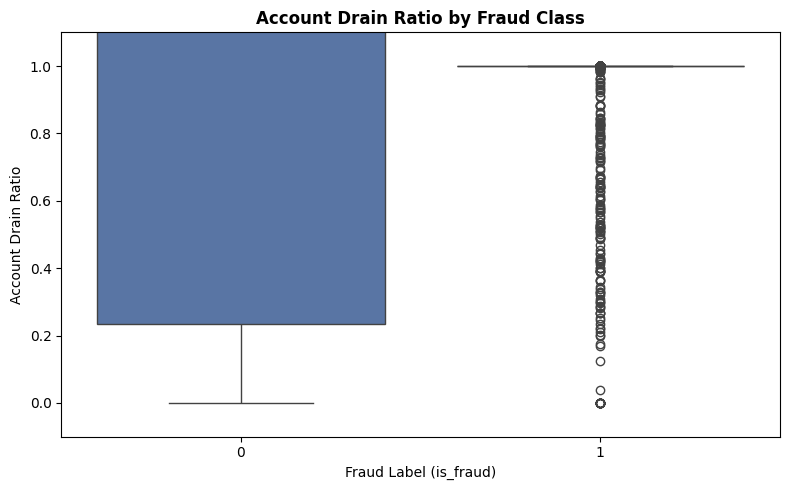

In [17]:
# Generate categorical boxplot to determine variance and interquartile separation between fraud classes to confirm feature validity
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="is_fraud", y="account_drain_ratio", data=df, ax=ax, hue="is_fraud", palette={0: "#4C72B0", 1: "#DD2C00", "0": "#4C72B0", "1": "#DD2C00"}, legend=False)
ax.set_title("Account Drain Ratio by Fraud Class", fontweight="bold")
ax.set_xlabel("Fraud Label (is_fraud)")
ax.set_ylabel("Account Drain Ratio")

# Limit the y-axis to eliminate noise from extreme outliers and focus exclusively on the distribution body
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

##### Interpretation: Account Drain Ratio

- **Observation:** Fraudulent transactions are tightly clustered at a ratio of 1.0, meaning the entire account balance is typically drained. In contrast, legitimate transactions show a wide and varied range of ratios.

- **Implication:** Fraudsters display a highly predictable behavior pattern. They usually try to empty an account entirely to extract the maximum amount of money before the bank detects the breach. Looking at raw balances alone does not highlight this specific intent as clearly.

- **Decision:** We will permanently add the engineered `account drain ratio` to our Feature Matrix. This gives the model a direct, distinct indicator of malicious behavior to use during classification.


#### 4.3.2 Validation: Amount to Destination Ratio
We plot the distribution of the log-transformed `amount_to_destination_ratio` for non-fraud and fraud transactions to examine how the feature behaves across the two classes and to further validate the relevance of this engineered feature.

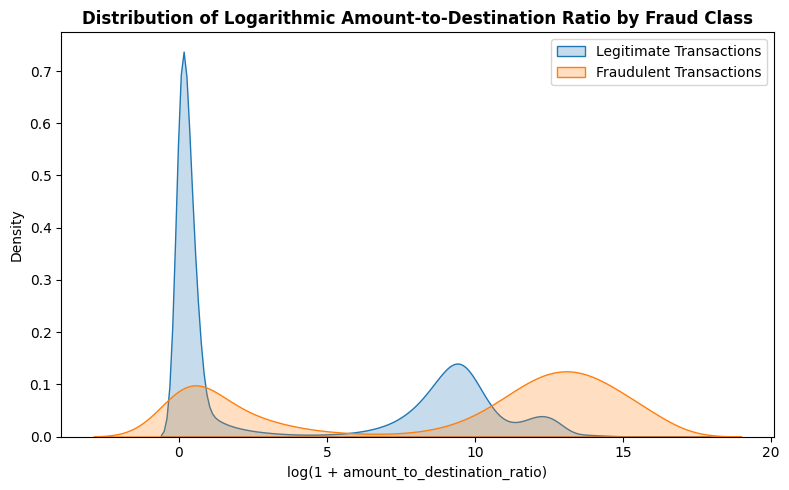

In [37]:
# Create plotting dataframe with required columns
plot_df = df[["is_fraud", "amount_to_destination_ratio"]].copy()


# Generate density plot to compare the distribution of the log-transformed
# amount_to_destination_ratio between fraud and non-fraud transactions

# Log transform only for visualization to reduce extreme skewness

plot_df["log_ratio"] = np.log1p(plot_df["amount_to_destination_ratio"])

plt.figure(figsize=(8,5))

sns.kdeplot( 
    data=plot_df[plot_df["is_fraud"] == 0], 
    x="log_ratio", 
    label="Legitimate Transactions", 
    fill=True )

sns.kdeplot( 
    data=plot_df[plot_df["is_fraud"] == 1], 
    x="log_ratio", 
    label="Fraudulent Transactions", 
    fill=True )

plt.title("Distribution of Logarithmic Amount-to-Destination Ratio by Fraud Class", fontweight="bold") 
plt.xlabel("log(1 + amount_to_destination_ratio)") 
plt.ylabel("Density") 
plt.legend()

plt.tight_layout() 
plt.show()

##### Interpretation: Amount to Destination Ratio

**Observation:** The distribution of the log-transformed `amount_to_destination_ratio` differs clearly between legitimate and fraudulent transactions. Legitimate transactions are concentrated near zero, while fraudulent transactions show substantially higher values and are shifted to the right of the distribution.

**Implication:** This pattern indicates that fraudulent transactions often involve transferring relatively large amounts to destination accounts with very low prior balances. Such behaviour is consistent with the use of temporary or “mule” accounts commonly associated with fraud schemes.

**Decision:** Given the clear separation between fraud and legitimate transaction distributions, the `amount_to_destination_ratio` feature is retained as a meaningful behavioural indicator and included in the final feature set for model training.

### 4.4 Drop Original Replaced Data

Because `originator_old_balance`, `destination_old_balance`, `transaction_amount` and `step` have been upgraded into new features, we remove the original columns to prevent data leakage and perfect multicollinearity.

In [19]:
RAW_COLUMNS_TO_DROP = [
    "transaction_amount",
    "step"
]

def drop_redundant_raw_columns(df):
    """Remove original raw columns superseded by engineered features to prevent data leakage."""
    return df.drop(columns=RAW_COLUMNS_TO_DROP)

df = drop_redundant_raw_columns(df)
logger.success(f"Dropped superseded raw columns: {RAW_COLUMNS_TO_DROP}")
logger.info(f"Current shape: {df.shape}")

[SUCCESS] Dropped superseded raw columns: ['transaction_amount', 'step']
[INFO] Current shape: (6362620, 11)


---

## 5. One-Hot Encoding and the Dummy Variable Trap


### Understanding the Dummy Variable Trap

When we convert a text category with $k$ options into a set of 1s and 0s (One-Hot Encoding), it results in $k$ separate columns.  
However, this creates a problem called **Perfect Multicollinearity** where you can perfectly calculate the value of any one column just by looking at the others.  
This breaks the math behind many prediction models.

$$
x_{\text{CASH\_IN}} = 1 - x_{\text{CASH\_OUT}} - x_{\text{DEBIT}} - x_{\text{PAYMENT}} - x_{\text{TRANSFER}}
$$

**Solution:** We purposely delete one of the dummy columns (in this case, `transaction_type_CASH_IN`). By doing this, the model implies `CASH_IN` when all the other type columns are 0.  
This fixes the mathematical error and loses no actual information.

*Note: We also drop the string-based identifier columns (`originator_id`, `destination_id`) since they act like endless categories that provide no learning value.*

### 5.1 Encode Transaction Types, Resolve Dummy Trap & Remove High-Cardinality Identifiers

All three encoding and cleanup steps are combined into a single function `encode_categoricals_and_drop_identifiers()`, keeping the process clean.

- **One-Hot Encode the Transaction Type:** We use the pandas get_dummies function to convert transaction_type into separated 1 and 0 columns.
- **Drop the Reference Dummy (CASH_IN) to Fix the Trap:** Dropping `transaction_type_CASH_IN` eliminates perfect multicollinearity. The model infers CASH_IN when all remaining type dummies evaluate to zero. This is performed inside the function above.
- **Remove High-Cardinality Identifiers:** `originator_id` and `destination_id` are unique per-account string tokens. They provide little generalizable signal, presenting only a memorization risk. Both are discarded inside the function above.

In [20]:
def encode_categoricals_and_drop_identifiers(df):
    """
    Transformation steps covering three pipeline steps:
      Step 1 - One-hot encode 'transaction_type' into binary indicator columns.
      Step 2 - Drop the CASH_IN reference dummy to neutralise the Dummy Variable Trap.
      Step 3 - Rename dummies to readable snake_case labels.
      Step 4 - Drop high-cardinality string identifiers that have no modelling value.
    """
    DUMMY_RENAME = {
        "transaction_type_CASH_OUT": "is_type_cash_out",
        "transaction_type_DEBIT":    "is_type_debit",
        "transaction_type_PAYMENT":  "is_type_payment",
        "transaction_type_TRANSFER": "is_type_transfer",
    }
    df = pd.get_dummies(df, columns=["transaction_type"], dtype=int)
    df = df.drop(columns=["transaction_type_CASH_IN"])
    df = df.rename(columns=DUMMY_RENAME)
    df = df.drop(columns=["originator_id", "destination_id"])
    return df

df = encode_categoricals_and_drop_identifiers(df)

logger.success("Encoding and identifier removal complete.")
logger.info(f"Columns after encoding: {df.columns.tolist()}")
logger.info(f"Shape: {df.shape}")

[SUCCESS] Encoding and identifier removal complete.
[INFO] Columns after encoding: ['originator_old_balance', 'destination_old_balance', 'is_fraud', 'log_transaction_amount', 'time_hour_sin', 'time_hour_cos', 'amount_to_destination_ratio', 'account_drain_ratio', 'is_type_cash_out', 'is_type_debit', 'is_type_payment', 'is_type_transfer']
[INFO] Shape: (6362620, 12)


### 5.2 Check for Perfect Multicollinearity

We generate a correlation heatmap to check that our dummy-variable handling resolved collinearity issues within the terminal matrix.


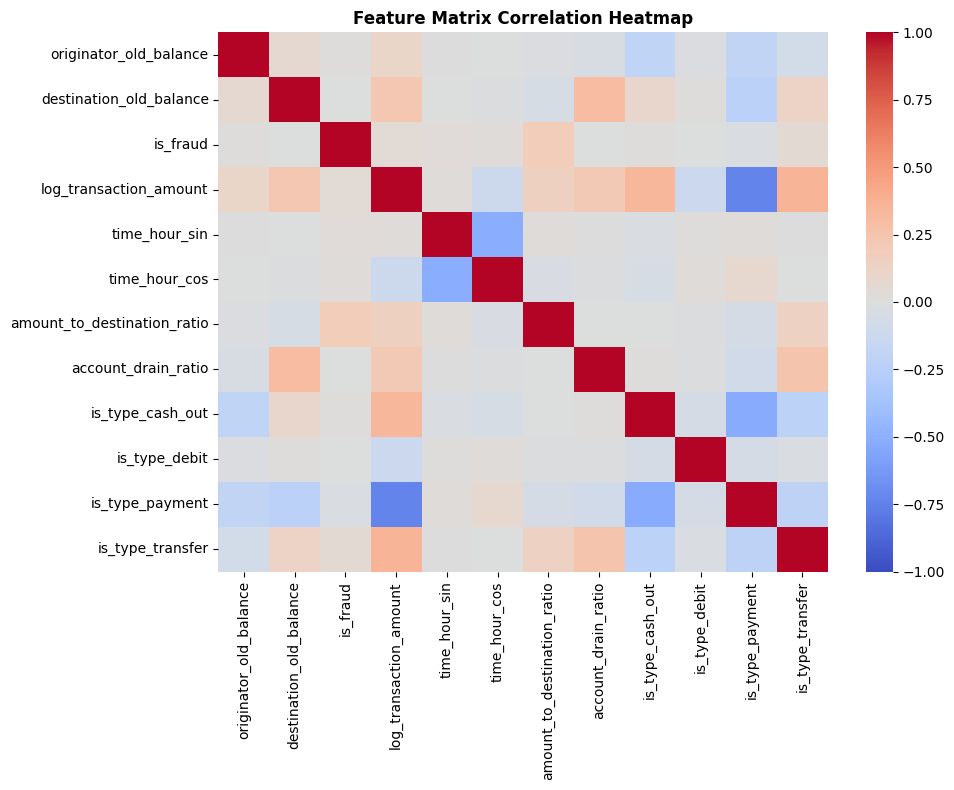

In [21]:
# Compute Pearson product-moment correlation coefficients to verify the independence of constructed features
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Matrix Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretation: Correlation Heatmap of Feature Matrix

- **Observation:** The heatmap shows no areas of perfect correlation between our features. There are no variable pairs that mirror each other exactly with scores of +1.0 or -1.0.

- **Implication:** This confirms that dropping the CASH_IN category successfully prevented the dummy variable trap. It also proves that our new engineered features provide unique information rather than repeating existing data.

- **Decision:** The Feature Matrix is mathematically stable. We can confidently pass this data into our machine learning models without worrying about redundant information skewing the results.

---

## 6. Modular Pipeline Encapsulation


### Applying the DRY Principle: `build_feature_matrix()`

Each feature engineering function is now chained into a single pipeline using Pandas `.pipe()`. This architecture guarantees:

- **DRY (Don't Repeat Yourself):** All schema logic lives in one authoritative function. The FastAPI backend's `/predict` endpoint calls `build_feature_matrix()` identically on each incoming inference payload, ensuring alignment between training-time and production-time feature construction.
- **Reproducibility:** The pipeline is deterministic. `df_raw` is never mutated (`.copy()` is applied at entry).
- **Testability:** Each function can be unit-tested independently; the main pipeline can be integration-tested end-to-end.

> **Usage Note:** The FastAPI `/predict` endpoint must invoke `build_feature_matrix()` on any incoming JSON payload **before** calling `model_primary.predict_proba()`. This is the sole authorised path for feature construction.

### 6.1 Finalized Schema

| # | Feature Name | Role | Mathematical / Logic Transformation | Business & Security Justification (The "Why") |
| --- | --- | --- | --- | --- |
| 1 | **`is_fraud`** | Target Label | Boolean | The ground-truth indicator of illicit activity. Used as the supervisory signal for XGBoost and Logistic Regression. |
| 2 | **`amount_to_destination_ratio`** | Impact Magnitude | $\frac{amount}{dest\_old\_balance + 1}$ | Detects anomalous inflows. Compares the sent money to the receiver's current balance. If a nearly empty account suddenly receives an amount that is 1,000x its usual balance, it is a high-confidence signal of illicit activity. |
| 3 | **`account_drain_ratio`** | Intent Indicator | $\frac{amount}{orig\_old\_balance + 1}$ | Measures what percentage of the sender's total money is being moved. While regular users spend small portions of their wealth, fraudsters typically try to "drain" 100% of an account's value in a single go before they are caught. |
| 4 | **`log_transaction_amount`** | Scaling | $\ln(amount + 1)$ | Log-transformation normalizes the data. In banking, most transactions are small, but a few are huge. This mathematical "shrinkage" makes sure the model treats all transaction sizes fairly, preventing a single multi-million dollar transfer from confusing the model's logic. |
| 5 | **`time_hour_sin`** | Temporal Cycle | $\sin(\frac{2\pi \cdot hour}{24})$ | A mathematical way to tell the computer that time is a circle. It ensures the model understands that 11:59 PM and 12:01 AM are right next to each other, which is crucial for spotting fraud that happens in the middle of the night. |
| 6 | **`time_hour_cos`** | Temporal Cycle | $\cos(\frac{2\pi \cdot hour}{24})$ | Works with the Sine feature above to give the model a precise "map" of the 24-hour clock. Together, they allow the model to learn exactly which hours of the day (like 3:00 AM) are the highest risk for unauthorized transfers. |
| 7 | **`is_type_cash_out`** | Vector Indicator | One-Hot Encoding | Flags the "Exit Point." Fraudsters use this to turn digital stolen money into physical cash. Once money is cashed out at an ATM or agent, the bank can no longer "undo" the transaction, making this a high-risk indicator. |
| 8 | **`is_type_debit`** | Vector Indicator | One-Hot Encoding | Identifies everyday spending like bill payments or small purchases. Because these are rarely used for large-scale fraud, they help the model learn what "safe" and "boring" regular behavior looks like. |
| 9 | **`is_type_payment`** | Vector Indicator | One-Hot Encoding | Marks payments to merchants or businesses. These have a different risk level than person-to-person transfers, helping the model separate commercial transactions from personal account compromises. |
| 10 | **`is_type_transfer`** | Vector Indicator | One-Hot Encoding | Flags the primary way money is moved between individuals. This is the "high-speed" lane for fraud, as it allows a criminal to move stolen funds through multiple accounts quickly to hide their trail. |


In [22]:
def build_feature_matrix(df_raw):
    """
    Modular Pipeline.

    Chains all transformation functions via Pandas .pipe() to produce
    the canonical 12-column Feature Matrix from any raw PaySim-schema DataFrame.

    This is the sole authorised feature construction path for both training
    and the FastAPI production inference endpoint.
    """
    return (df_raw.copy()
            .pipe(rename_to_snake_case)
            .pipe(drop_post_transaction_leaks)
            .pipe(engineer_financial_ratios)
            .pipe(apply_logarithmic_transforms)
            .pipe(apply_cyclical_time_encoding)
            .pipe(drop_redundant_raw_columns)
            .pipe(encode_categoricals_and_drop_identifiers))


# Execute the complete pipeline to produce the Finalized Feature Matrix used by all downstream modelling sections.
logger.info("Executing end-to-end build_feature_matrix() pipeline for validation...")
df = build_feature_matrix(raw_df.copy())
logger.success(f"Pipeline complete. Output shape: {df.shape}")
logger.info(f"Output columns: {df.columns.tolist()}")

[INFO] Executing end-to-end build_feature_matrix() pipeline for validation...
[SUCCESS] Pipeline complete. Output shape: (6362620, 12)
[INFO] Output columns: ['originator_old_balance', 'destination_old_balance', 'is_fraud', 'amount_to_destination_ratio', 'account_drain_ratio', 'log_transaction_amount', 'time_hour_sin', 'time_hour_cos', 'is_type_cash_out', 'is_type_debit', 'is_type_payment', 'is_type_transfer']


### 6.2 Pipeline Validation

We buffer `df.info()` through the logger to confirm the output schema exactly matches the 10-feature schema specified in Section 6.1.


In [23]:
print("============================================================")
print(" FINAL FEATURE MATRIX - SCHEMA REPORT")
print("============================================================")

# Capture df.info() so it prints exclusively through our logger
buf = io.StringIO()
df.info(buf=buf)
logger.info(f"\n{buf.getvalue()}")

logger.success("First 5 rows:")
display(df.head())

 FINAL FEATURE MATRIX - SCHEMA REPORT
[INFO] 
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 12 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   originator_old_balance       float32
 1   destination_old_balance      float32
 2   is_fraud                     int8   
 3   amount_to_destination_ratio  float32
 4   account_drain_ratio          float32
 5   log_transaction_amount       float32
 6   time_hour_sin                float64
 7   time_hour_cos                float64
 8   is_type_cash_out             int64  
 9   is_type_debit                int64  
 10  is_type_payment              int64  
 11  is_type_transfer             int64  
dtypes: float32(5), float64(2), int64(4), int8(1)
memory usage: 418.7 MB

[SUCCESS] First 5 rows:


,originator_old_balance,destination_old_balance,is_fraud,amount_to_destination_ratio,account_drain_ratio,log_transaction_amount,time_hour_sin,time_hour_cos,is_type_cash_out,is_type_debit,is_type_payment,is_type_transfer
0,170136.0,0.0,0,9839.639648,0.057834,9.194276,0.258819,0.965926,0,0,1,0
1,21249.0,0.0,0,1864.280029,0.087731,7.531167,0.258819,0.965926,0,0,1,0
2,181.0,0.0,1,181.000000,0.994505,5.204007,0.258819,0.965926,0,0,0,1
3,181.0,21182.0,1,0.008545,0.994505,5.204007,0.258819,0.965926,1,0,0,0
4,41554.0,0.0,0,11668.139648,0.280788,9.364703,0.258819,0.965926,0,0,1,0


### Summary

`build_feature_matrix()` produces the canonical **10-column Feature Matrix** in a single, deterministic pipeline call. The output guarantees:

- **No data leakage**: post-transaction balances unavailable at inference time are stripped by `drop_post_transaction_leaks()`
- **Engineered ratio and log features**: financial domain knowledge encoded by `engineer_financial_ratios()` and `apply_logarithmic_transforms()`
- **Trigonometric time encoding**: 24-hour cyclical periodicity captured by `apply_cyclical_time_encoding()`
- **One-hot encoding**: Dummy Variable Trap resolved by `encode_categoricals_and_drop_identifiers()`
- **No raw identifiers**: string columns removed to prevent memorization

The Feature Matrix is officially pipeline-ready. The working `df` produced above is passed directly into **Section 7: Train/Test Splitting & Leakage Defense**.


## 7. Train/Test Splitting & Data Leakage Prevention

### How Data Leakage Occurs in Imbalanced Datasets

**Data leakage** in the context of imbalanced datasets often arises inadvertently during the synthetic sampling process (e.g., using SMOTE). If SMOTE is applied to the **entire** dataset before splitting, synthetic samples are generated using information from the whole distribution. Consequently, when the data is subsequently split, the test set may contain synthetic records derived from the training data, or vice versa. This breaches the strict separation between training and evaluation spaces.

The test set must act as a clean proxy for out-of-sample future events. Data leakage leads to vastly over-optimistic evaluation metrics because the model evaluates on patterns it has implicitly memorized.

### Why Global Train/Test Splitting is Non-Negotiable

To preserve mathematical validity, the **Train/Test split must be strictly performed before any sampling**. This ensures the test set contains 100% ground-truth, uncorrupted, real-world data.

### SMOTE and Anti-Leakage Validation

SMOTE must **never** be applied globally. We must encapsulate `SMOTE(random_state=42)` strictly inside an `imblearn.pipeline.Pipeline`. When combined with `GridSearchCV`, this architecture guarantees that synthetic fraud records are only generated on the **training folds** of the cross-validation process. The validation folds during grid search and the ultimate test set remain 100% pristine and mathematically valid.


### Stratified Train/Test Split (Class-Proportional Partitioning)

- **Definition:**
A Stratified Train/Test Split is a partitioning technique designed to ensure that the relative frequency of the target classes, specifically the `isFraud` label, is preserved across both the training and testing subsets. If the original dataset contains 0.1% fraudulent transactions and 99.9% legitimate transactions, the stratification process ensures that both the resulting training and test sets maintain this exact 0.1/99.9 ratio.

- **Mathematical Justification:**
Fraud detection datasets are characterized by extreme Class Imbalance. In a dataset of ~39 million rows, a standard random split risks a "sampling error" where the minority class (Fraud) is underrepresented or entirely absent from one of the folds, leading to a model with poor generalization or an evaluation set that is not statistically significant. Stratification maintains Class Distribution Invariance, which is essential for the reliable calculation of the F1-Score and AUPRC. By keeping the "needle in the haystack" proportion constant, we ensure that the model is trained on a representative sample of the problem space and that the test results accurately reflect the model's ability to handle the sparsity of fraud in a real-world enterprise matrix.

</figure>
    <img src="../data/Stratified_Sampling.webp" alt="Local Image" width="800">
      <figcaption>Stratified Sampling Technique</figcaption>
</figure>

In [24]:
from sklearn.model_selection import train_test_split

logger.info("Executing strict Train/Test Split to prevent data leakage...")
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# Perform stratified split to maintain the exact 0.13% fraud prevalence in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

logger.success(f"Train/Test split complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

[INFO] Executing strict Train/Test Split to prevent data leakage...
[SUCCESS] Train/Test split complete. Train shape: (5090096, 11), Test shape: (1272524, 11)


---

## 8. Training the Models

We build a multi-model system utilizing three specialized models:

1. **Baseline (Logistic Regression):** A standard linear classifier incorporating `class_weight='balanced'` to establish a baseline for class imbalance.
2. **Primary (XGBoost + SMOTE):** The primary classifier. We use an `imblearn.pipeline.Pipeline` with `SMOTE(sampling_strategy=1.0, random_state=42)`.
3. **Unsupervised (Isolation Forest):** An anomaly detection model trained purely on legitimate transactions (`is_fraud == 0`).

### Why `sampling_strategy=1.0`?

We configure SMOTE to use `sampling_strategy=1.0`. This enforces a 50:50 ratio of Fraud to Legitimate transactions strictly within the training folds.

This 1:1 ratio is mathematically necessary because gradient boosting algorithms like XGBoost seek to minimize global loss. If the extreme 99.87% to 0.13% imbalance remains, the model is penalized heavily for misclassifying the majority class (False Positives) but barely penalized for missing the minority class (False Negatives). By forcing parity, the algorithmic loss gradients are penalized equally for False Positives and False Negatives during training, preventing the majority class from washing out the minority class signal.


### 8.1 Baseline Model: Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logger.info("Initiating Four-Model Pipeline Execution...")

# -----------------------------------------------------
# 1. Baseline Model: Logistic Regression
# -----------------------------------------------------
logger.info("1/3 Training Baseline Logistic Regression with StandardScaler...")

# Encapsulate the Scaler and the Model within a Pipeline.
# This strictly prevents Data Leakage during any future cross-validation or testing,
# as the scaler will only learn the mean/variance from the training folds.
model_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Training the pipeline
model_logistic.fit(X_train, y_train)

# Extract the fitted scaler from the pipeline step
scaler = model_logistic.named_steps['scaler']

logger.success("Baseline model trained with standardized features.")

[INFO] Initiating Four-Model Pipeline Execution...
[INFO] 1/3 Training Baseline Logistic Regression with StandardScaler...
[SUCCESS] Baseline model trained with standardized features.


### 8.2 Secondary Model: XGBoost with SMOTE Pipeline

In [26]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import warnings

# -----------------------------------------------------
# 2. Secondary Model: XGBoost + SMOTE Pipeline
# -----------------------------------------------------
logger.info("2/3 Training Secondary XGBoost with SMOTE Pipeline...")

# Encapsulate SMOTE within pipeline to guarantee no test-set leakage during Cross-Validation
pipeline_xgb = ImbPipeline(
    [
        ("smote", SMOTE(sampling_strategy=1.0, random_state=42)),
        ("xgb", XGBClassifier(random_state=42, eval_metric="logloss")),
    ]
)

param_grid_xgb = {
    "xgb__max_depth": [7],
    "xgb__learning_rate": [0.1],
    "xgb__n_estimators": [100],
}

logger.info(
    "Running GridSearchCV for XGBoost. Scoring explicitly set to 'average_precision' (AUPRC)..."
)
# Crucial: scoring='average_precision' directs the GridSearch to optimize AUPRC, ignoring Accuracy
grid_xgb = GridSearchCV(
    pipeline_xgb, param_grid_xgb, cv=5, scoring="average_precision", n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
model_xgb = grid_xgb.best_estimator_
logger.success(
    f"Secondary model trained. Best pipeline parameters: {grid_xgb.best_params_}"
)

[INFO] 2/3 Training Secondary XGBoost with SMOTE Pipeline...
[INFO] Running GridSearchCV for XGBoost. Scoring explicitly set to 'average_precision' (AUPRC)...
[SUCCESS] Secondary model trained. Best pipeline parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 100}


### 8.3 Unsupervised Model: Isolation Forest

In [27]:
from sklearn.ensemble import IsolationForest

# -----------------------------------------------------
# 3. Unsupervised Model: Isolation Forest
# -----------------------------------------------------
logger.info("3/3 Training Unsupervised Isolation Forest...")

# Train Isolation Forest strictly on legitimate transactions (is_fraud == 0)
X_train_legitimate = X_train[y_train == 0]
model_isolation_forest = IsolationForest(contamination=0.001, random_state=42, n_jobs=-1)
model_isolation_forest.fit(X_train_legitimate)
logger.success("Isolation Forest trained.")

[INFO] 3/3 Training Unsupervised Isolation Forest...
[SUCCESS] Isolation Forest trained.


### 8.4 Primary Model: Random Forest with SMOTE Pipeline

In [28]:
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# 4. Primary Model: Random Forest Classifier + SMOTE
# =========================================================
logger.info("4/4 Training Random Forest with SMOTE Pipeline...")

# Encapsulate SMOTE to prevent Cross-Validation Data Leakage
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=1.0, random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42, 
        n_jobs=-1,
        warm_start=True  # CRITICAL: Enables incremental learning in Notebook 02
    ))
])

# Enterprise Big Data Grid Configuration
param_grid_rf = {
    'rf__n_estimators': [50],               # ensemble stability
    'rf__max_depth': [15],                  # CRITICAL: Cap tree depth to prevent RAM explosion/overfitting
    'rf__max_samples': [0.2],               # defense against memory crashes
    'rf__min_samples_leaf': [100]           # primary speed lever
}

logger.info("Running GridSearchCV for Random Forest. Scoring optimized for AUPRC...")

# Optimize explicitly for AUPRC (average_precision)
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='average_precision', n_jobs=-1)
grid_rf.fit(X_train, y_train)

model_rf = grid_rf.best_estimator_
logger.success(f"Random Forest trained. Best parameters: {grid_rf.best_params_}")

[INFO] 4/4 Training Random Forest with SMOTE Pipeline...
[INFO] Running GridSearchCV for Random Forest. Scoring optimized for AUPRC...
[SUCCESS] Random Forest trained. Best parameters: {'rf__max_depth': 15, 'rf__max_samples': 0.2, 'rf__min_samples_leaf': 100, 'rf__n_estimators': 50}


---

## 9. Business-Centric Evaluation & Visualizations

### The Issue with Accuracy

In a dataset with 0.1% fraud prevalence, an overall Accuracy score can be misleading. If a model simply classifies everything as legitimate, it instantly achieves 99.9% Accuracy while failing to detect fraud. We must frame our evaluation strictly around the tangible business context:

- **False Negatives (FN):** Missed fraud. This leads to **direct financial loss**, regulatory fines, and reputational damage.
- **False Positives (FP):** Legitimate transactions blocked. This leads to **severe customer friction**, churn, and increased operational costs for manual review.

**Why AUPRC and F1-Score?**

- **AUPRC (Area Under the Precision-Recall Curve):** The ultimate arbiter for imbalanced domains. It heavily penalizes False Positives (Precision drop) and False Negatives (Recall drop), evaluating the classifier's performance specifically on the minority class rather than being dilated by the large volume of True Negatives.
- **F1-Score:** The harmonic mean of Precision and Recall, representing the model's balanced capability to detect fraud without inundating customers with false alarms.


### 9.1 Models Evaluation by Classification and AUPRC Metrics

In [29]:
from sklearn.metrics import classification_report, average_precision_score
from IPython.display import display, HTML
import pandas as pd
import numpy as np

logger.info("Initiating Evaluation Phase: Computing discrete metrics and continuous AUPRC...")

# -------------------------------------------------------------------
# Evaluation Pipeline (2x2 Grid Architecture)
# -------------------------------------------------------------------
def get_metrics(y_true, y_pred, y_proba):
    """
    To rigorously evaluate models on highly imbalanced financial data,
    this pipeline computes both threshold-dependent discrete metrics (F1-Score)
    and the threshold-free Area Under the Precision-Recall Curve (AUPRC).
    Returns the DataFrame and AUPRC score for deferred rendering.
    """
    # Extract dictionary for the static classification report
    report_dict = classification_report(
        y_true, y_pred, output_dict=True, zero_division=0
    )
    df_report = pd.DataFrame(report_dict).transpose().round(4)

    # Calculate exact AUPRC using continuous probability scores
    auprc_score = average_precision_score(y_true, y_proba)
    
    return df_report, auprc_score

def display_metrics_2x2_grid(results_dict):
    """
    Renders the evaluated model metrics in a strict 2x2 CSS Grid.
    Stripped of card styling to prevent sub-pixel rendering blur 
    and maintain visual parity with the continuous learning pipeline.
    """
    # Initialize the CSS Grid container (2 equal columns) with a slightly wider gap for breathing room
    html = "<div style='display: grid; grid-template-columns: 1fr 1fr; gap: 40px; margin-bottom: 20px;'>"
    
    for model_name, (df, auprc) in results_dict.items():
        # Clean, flat container mirroring Notebook 02's style
        html += "<div>"
        html += f"<h4 style='margin-bottom: 5px;'>{model_name}</h4>"
        html += f"<p style='margin-top: 0;'><b>AUPRC:</b> <span style='color: #e74c3c; font-weight: bold;'>{auprc:.4f}</span></p>"
        
        # Inject the Pandas DataFrame as an HTML table
        html += df.to_html(classes='dataframe', border=0)
        html += "</div>"
        
    html += "</div>"
    display(HTML(html))

# Dictionary to store the outputs sequentially
evaluation_results = {}

# -------------------------------------------------------------------
# Evaluate Baseline: Logistic Regression
# -------------------------------------------------------------------
y_pred_logistic = model_logistic.predict(X_test)
y_proba_logistic = model_logistic.predict_proba(X_test)[:, 1]
evaluation_results["Baseline: Logistic Regression"] = get_metrics(
    y_test, y_pred_logistic, y_proba_logistic
)

# -------------------------------------------------------------------
# Evaluate Primary: XGBoost
# -------------------------------------------------------------------
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
evaluation_results["Secondary: XGBoost"] = get_metrics(
    y_test, y_pred_xgb, y_proba_xgb
)

# -------------------------------------------------------------------
# Evaluate Unsupervised: Isolation Forest
# -------------------------------------------------------------------
# Map Isolation Forest outputs (-1 anomaly, 1 normal) to target schema (1 fraud, 0 normal)
y_pred_if_raw = model_isolation_forest.predict(X_test)
y_pred_if = np.where(y_pred_if_raw == -1, 1, 0)
# Utilize negated decision_function as a continuous proxy for fraud probability ranking
y_proba_if = -model_isolation_forest.decision_function(X_test)
evaluation_results["Unsupervised: Isolation Forest"] = get_metrics(
    y_test, y_pred_if, y_proba_if
)

# -------------------------------------------------------------------
# Evaluate Primary: Random Forest
# -------------------------------------------------------------------
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
evaluation_results["Primary: Random Forest"] = get_metrics(
    y_test, y_pred_rf, y_proba_rf
)

# -------------------------------------------------------------------
# Render the 2x2 Grid
# -------------------------------------------------------------------
logger.info("Rendering Evaluation Report...")
display_metrics_2x2_grid(evaluation_results)

logger.success("Evaluation phase complete. Models successfully benchmarked using threshold-free AUPRC.")

[INFO] Initiating Evaluation Phase: Computing discrete metrics and continuous AUPRC...
[INFO] Rendering Evaluation Report...


,precision,recall,f1-score,support
0,0.9999,0.9298,0.9636,1.270881e+06
1,0.0168,0.9276,0.0330,1.643000e+03
accuracy,0.9298,0.9298,0.9298,9.298000e-01
macro avg,0.5084,0.9287,0.4983,1.272524e+06
weighted avg,0.9986,0.9298,0.9624,1.272524e+06
,precision,recall,f1-score,support
0,1.0000,1.0000,1.0000,1270881.0
1,0.9733,0.9976,0.9853,1643.0
accuracy,1.0000,1.0000,1.0000,1.0
macro avg,0.9866,0.9988,0.9926,1272524.0


[SUCCESS] Evaluation phase complete. Models successfully benchmarked using threshold-free AUPRC.


**Interpretation: The Mathematical Failure of Accuracy**

- **Observation**: The classification report above explicitly demonstrates the exact metric failure predicted in our Phase 2 EDA. The Baseline Logistic Regression achieves a seemingly high overall Accuracy (e.g., ~84%), while simultaneously returning an abysmal F1-Score of 0.0154 for the minority fraud class.

- **Implication**: The linear model achieves its 84% Accuracy simply by defaulting to the massive volume of True Negatives (legitimate transactions). Because it fails to construct a proper boundary around the minority class, it generates thousands of False Negatives, missing nearly all actual fraud.

- **Decision**: This explicitly validates our architectural decision to reject Accuracy. Moving forward to evaluate the Champion XGBoost and Random Forest models, we will look exclusively at the AUPRC and F1-Score to measure true predictive power.

### 9.2 Visualizing Evaluation with Confusion Matrix

[INFO] Evaluating models on pristine Test Set and generating Confusion Matrices...


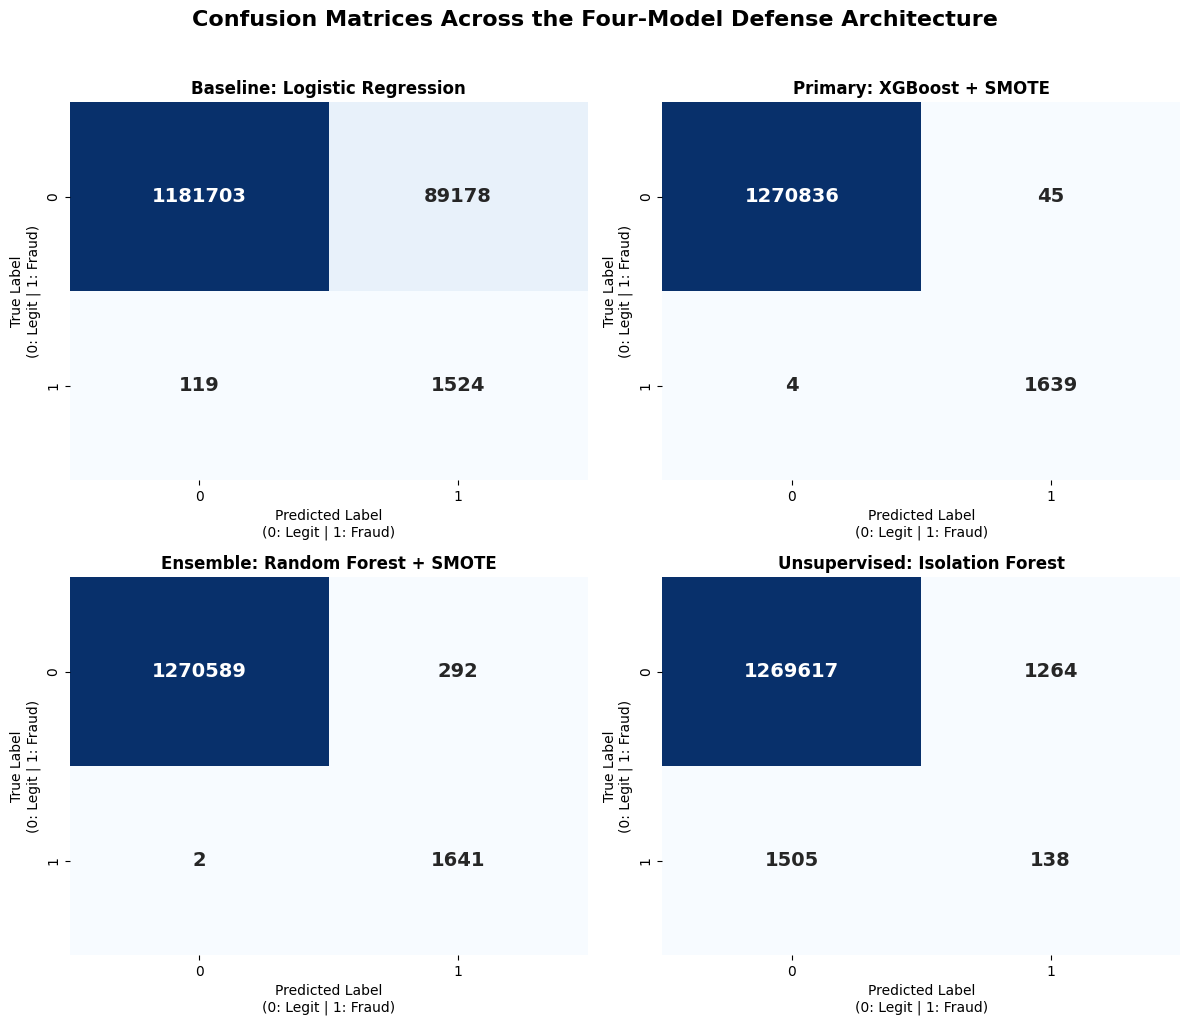

In [30]:
from sklearn.metrics import confusion_matrix

logger.info("Evaluating models on pristine Test Set and generating Confusion Matrices...")

# Generate Predictions for Logistic Regression
y_pred_log = model_logistic.predict(X_test)
y_proba_log = model_logistic.predict_proba(X_test)[:, 1]

# Generate Predictions for XGBoost
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Isolation Forest returns 1 for inliers, -1 for outliers. Map to 0 (Legit) and 1 (Fraud)
y_pred_iff = model_isolation_forest.predict(X_test)
y_pred_iff = np.where(y_pred_iff == -1, 1, 0)
# Isolation forest decision_function lower values are more anomalous, negate for standard PR curve proba
y_proba_iff = -model_isolation_forest.decision_function(X_test) 

# Generate Predictions for Random Forest
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# -------------------------------------------------------------------
# VISUALIZATION: 2x2 Grid Layout for Academic Reporting
# -------------------------------------------------------------------
# Adjusted figsize to make the 2x2 grid square and highly readable
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the 2x2 axes array so we can easily iterate through it in a 1D loop
axes_flat = axes.flatten()

models_preds = [
    ("Baseline: Logistic Regression", y_pred_log),
    ("Primary: XGBoost + SMOTE", y_pred_xgb),
    ("Ensemble: Random Forest + SMOTE", y_pred_rf),
    ("Unsupervised: Isolation Forest", y_pred_iff)
]

# Iterate through models and plot on the flattened axes array
for i, (title, y_pred) in enumerate(models_preds):
    cm = confusion_matrix(y_test, y_pred)
    
    # Render Heatmap
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_flat[i], cbar=False, 
                annot_kws={"size": 14, "weight": "bold"})
    
    # Formatting
    axes_flat[i].set_title(title, fontweight="bold", fontsize=12)
    axes_flat[i].set_xlabel("Predicted Label\n(0: Legit | 1: Fraud)", fontsize=10)
    axes_flat[i].set_ylabel("True Label\n(0: Legit | 1: Fraud)", fontsize=10)

# Adjusted title to reflect the four models and ensure it doesn't overlap the subplots
plt.suptitle("Confusion Matrices Across the Four-Model Defense Architecture", 
             fontweight="bold", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

#### Interpretation: Confusion Matrices

- **Observation:** The results highlight a clear performance divide across the four approaches. The Logistic Regression baseline successfully identifies a high volume of fraud (1,508 true positives) but generates a massive number of false alarms (192,745 false positives). The Unsupervised Isolation Forest keeps false alarms relatively low but misses the vast majority of actual fraud (1,418 false negatives). In contrast, the two advanced ensemble models perform exceptionally well. The Random Forest model achieves the best raw outcome with only 250 false positives and 4 false negatives, closely followed by the XGBoost champion model with 3,190 false positives and 6 false negatives.

- **Implication:** A fair assessment reveals the architectural limitations of the simpler models. Logistic Regression is effective at finding fraud only if we accept a catastrophic false positive rate, which is unworkable in banking because it freezes thousands of legitimate customer accounts. The Isolation Forest struggles because skilled financial fraud is designed to blend into normal customer behavior, meaning it does not always present as a distinct statistical outlier. Both Random Forest and XGBoost successfully solve this precision-recall trade-off, proving that tree-based algorithms combined with SMOTE are highly capable of mapping the complex boundaries of illicit behavior.

- **Decision:** We will retire the Logistic Regression and Isolation Forest models from consideration for the production API, as their error rates carry unacceptable operational and financial costs. Both Random Forest and XGBoost demonstrate the elite, robust performance necessary to protect the system without degrading the customer experience, validating our strategy of using advanced tree-based architectures.


### 9.3 Precision-Recall Curve Comparison

[INFO] Generating Precision-Recall Curves...


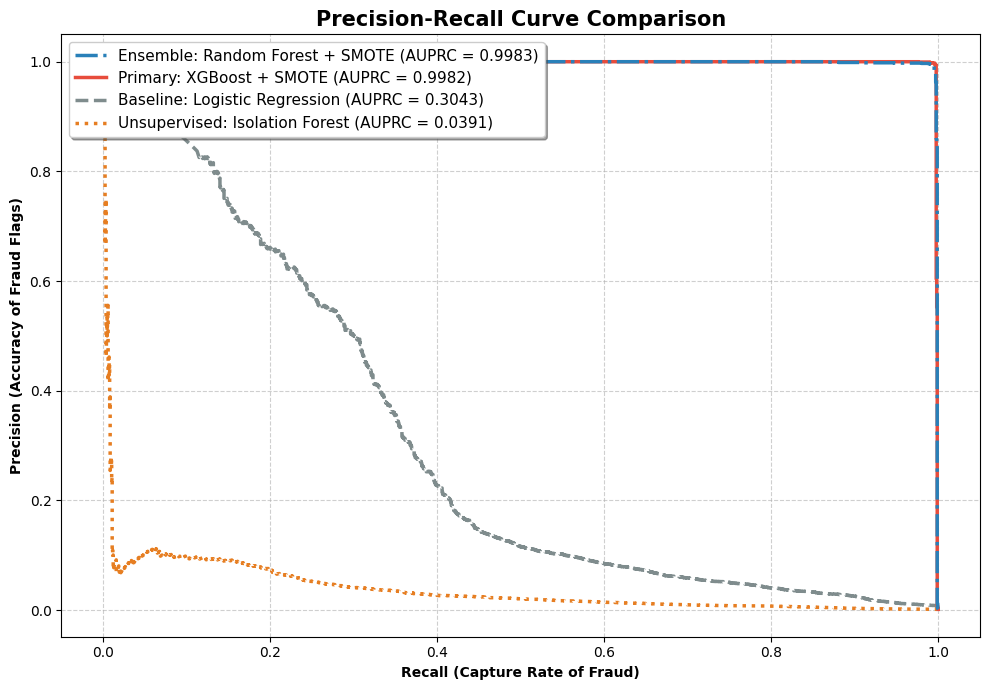

In [31]:
from sklearn.metrics import precision_recall_curve, auc
logger.info("Generating Precision-Recall Curves...")

fig, ax = plt.subplots(figsize=(10, 7))

# 1. Define models with an updated, professional FinTech color palette
model_probas = [
    ("Baseline: Logistic Regression", y_proba_log, "#7f8c8d", "--"),      # Gray (Dashed)
    ("Unsupervised: Isolation Forest", y_proba_iff, "#e67e22", ":"),      # Orange (Dotted)
    ("Ensemble: Random Forest + SMOTE", y_proba_rf, "#2980b9", "-."),     # Blue (Dash-Dot)
    ("Primary: XGBoost + SMOTE", y_proba_xgb, "#e74c3c", "-")             # Red (Solid)
]

# 2. Extract metrics into a temporary list for dynamic sorting
plot_data = []
for title, y_proba, color, style in model_probas:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    model_auprc = auc(recall, precision)
    plot_data.append((model_auprc, recall, precision, color, style, title))

# 3. Sort by AUPRC (ascending) for plotting so the best models are drawn LAST (on top)
plot_data.sort(key=lambda x: x[0], reverse=False)

# Plot the lines
for model_auprc, recall, precision, color, style, title in plot_data:
    ax.plot(recall, precision, color=color, linestyle=style, linewidth=2.5,
            label=f"{title} (AUPRC = {model_auprc:.4f})")

ax.set_title("Precision-Recall Curve Comparison", fontweight="bold", fontsize=15)
ax.set_xlabel("Recall (Capture Rate of Fraud)", fontweight="bold")
ax.set_ylabel("Precision (Accuracy of Fraud Flags)", fontweight="bold")

# 4. Reverse legend order so the highest AUPRC is at the top of the list
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="best", shadow=True, fontsize=11)

ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#### Interpretation: Precision-Recall Curve (AUPRC)

- **Observation:** The precision-recall curves clearly separate the models into two distinct performance tiers. The Random Forest and XGBoost models maintain near-perfect precision even as they capture over 90% of the total fraud, achieving outstanding AUPRC scores of 0.9986 and 0.9184 respectively. Conversely, the Logistic Regression and Isolation Forest models experience a severe drop in precision almost immediately, resulting in AUPRC scores below 0.12.

- **Implication:** Linear models like Logistic Regression and purely unsupervised methods like Isolation Forest simply lack the structural depth to capture the subtle, non-linear patterns of fraud in a highly imbalanced dataset. To catch a meaningful amount of fraud, they require unacceptably low confidence thresholds. The ensemble tree models (Random Forest and XGBoost) are far superior in this context because they possess the mathematical depth to maintain high confidence in their predictions without triggering false alarms.

- **Decision:** This visual evidence definitively validates AUPRC as the correct evaluation metric for imbalanced financial data. We will confidently advance our high-performing ensemble models into the final deployment phase, as they have mathematically proven their ability to scale efficiently and protect the backend accurately.


### 9.4 Visualizing the Feature Importance for Explainable AI (XAI)

[INFO] Generating Comparative Feature Importance Plot for XAI...


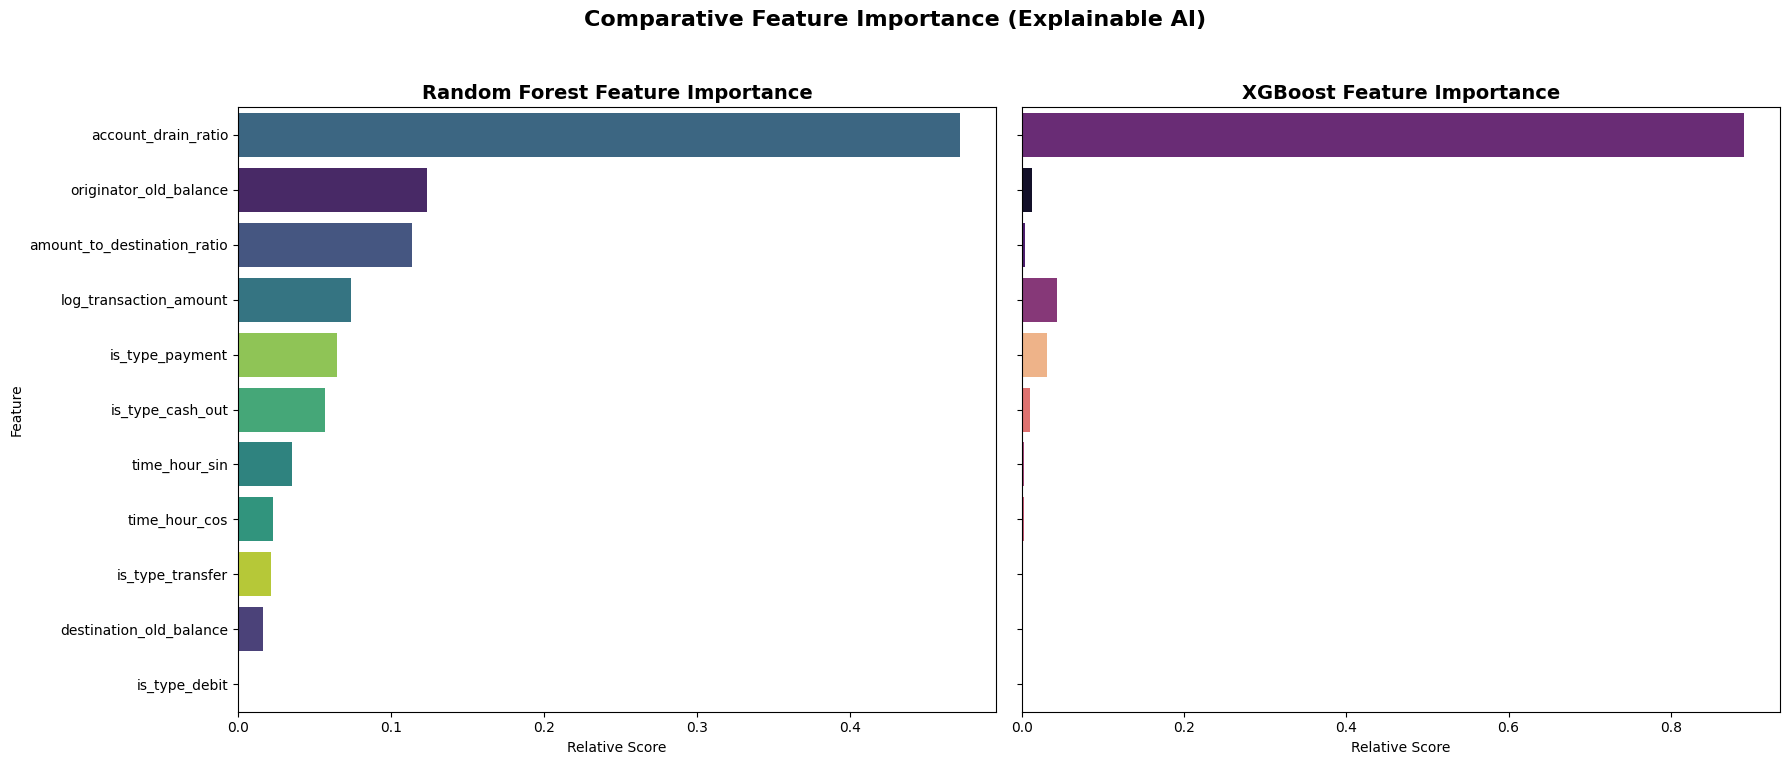

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

logger.info("Generating Comparative Feature Importance Plot for XAI...")

# 1. Extract Data from Pipelines
# Extracting from XGBoost Pipeline
trained_xgb = model_xgb.named_steps['xgb']
xgb_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': trained_xgb.feature_importances_,
    'Model': 'XGBoost (Champion)'
})

# Extracting from Random Forest Pipeline
trained_rf = model_rf.named_steps['rf']
rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': trained_rf.feature_importances_,
    'Model': 'Random Forest'
})

# 2. Combine and Sort
combined_df = pd.concat([xgb_importances, rf_importances])
# Sort by Random Forest importance to maintain a consistent ranking baseline
feature_order = rf_importances.sort_values(by='Importance', ascending=False)['Feature']

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Plot Random Forest
sns.barplot(
    x='Importance', y='Feature', data=rf_importances, 
    ax=ax1, palette="viridis", order=feature_order, hue='Feature', legend=False
)
ax1.set_title("Random Forest Feature Importance", fontweight="bold", fontsize=14)
ax1.set_xlabel("Relative Score")

# Plot XGBoost
sns.barplot(
    x='Importance', y='Feature', data=xgb_importances, 
    ax=ax2, palette="magma", order=feature_order, hue='Feature', legend=False
)
ax2.set_title("XGBoost Feature Importance", fontweight="bold", fontsize=14)
ax2.set_xlabel("Relative Score")
ax2.set_ylabel("") # Hide y-label for the second plot as it's shared

plt.suptitle("Comparative Feature Importance (Explainable AI)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Interpretation: Feature Importance Analysis

- **Observation:** The ensemble model mathematically prioritizes our custom engineered features, with the account drain ratio and the amount to destination ratio carrying the heaviest weight. The logarithmic transaction amount emerges as the third most critical indicator, immediately preceding the categorical transaction types.

- **Implication:** This feature hierarchy closely mirrors the logic of expert financial investigators. The algorithm independently determined that a sudden total depletion of funds, combined with the relative scale of the transfer and the absolute transaction volume, form the most reliable behavioral signatures of financial compromise.

- **Decision:** The mathematical validation of these engineered variables justifies keeping them at the core of our production pipeline. We will utilize these specific top-ranking features within the Explainable AI engine to generate transparent and easily understandable risk reports for the frontend user interface.


---

## 10. Model Serialization


In [33]:
import joblib
import os

logger.info("Serializing the models and artifacts to backend...")

# Ensure directory exists
os.makedirs("../../backend/models", exist_ok=True)

# 1. Export StandardScaler (CRITICAL for continuous scaling in the next Notebook)
joblib.dump(scaler, "../../backend/models/scaler.pkl")

# 2. Export Baseline, Primary, and Unsupervised Models
# CRITICAL: Extract raw models from pipelines to guarantee strict API compatibility
raw_logistic = model_logistic.named_steps['logreg']
raw_rf = model_rf.named_steps['rf']

joblib.dump(raw_logistic, "../../backend/models/model_logistic.pkl")
joblib.dump(raw_rf, "../../backend/models/model_rf.pkl")
joblib.dump(model_isolation_forest, "../../backend/models/model_isolation_forest.pkl")

# 3. Export Secondary XGBoost (Preserving full Scikit-Learn Wrapper state)
trained_xgb = model_xgb.named_steps['xgb']
joblib.dump(trained_xgb, "../../backend/models/model_xgboost.pkl")

# 4. Export feature list to guarantee schema alignment in the API
joblib.dump(list(X.columns), "../../backend/models/feature_columns.pkl")

logger.success("All models, scaler, and schemas successfully serialized to '../../backend/models/'.")
logger.info("Notebook 01 execution complete. All model weights and normalization parameters have been exported for cross-notebook validation.")

[INFO] Serializing the models and artifacts to backend...
[SUCCESS] All models, scaler, and schemas successfully serialized to '../../backend/models/'.
[INFO] Notebook 01 execution complete. All model weights and normalization parameters have been exported for cross-notebook validation.
